In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ransap-feature-extracted2/RANSAP_win7-120gb-ssd_12CLASS.npy
/kaggle/input/ransap-feature-extracted2/RANSAP_win7-250gb-ssd_26CLASS.npy
/kaggle/input/ransap-feature-extracted2/RANSAP_win7-250gb-ssd_2CLASS.npy
/kaggle/input/ransap-feature-extracted2/RANSAP_win7-250gb-hdd_12CLASS.npy
/kaggle/input/ransap-feature-extracted2/combined_RANSAP_12CLASS.npy
/kaggle/input/ransap-feature-extracted2/RANSAP_win7-120gb-ssd_26CLASS.npy
/kaggle/input/ransap-feature-extracted2/RANSAP_win7-250gb-ssd_12CLASS.npy
/kaggle/input/ransap-feature-extracted2/RANSAP_win7-250gb-hdd_2CLASS.npy
/kaggle/input/ransap-feature-extracted2/combined_RANSAP_26CLASS.npy
/kaggle/input/ransap-feature-extracted2/combined_RANSAP_2CLASS.npy
/kaggle/input/ransap-feature-extracted2/RANSAP_win7-250gb-hdd_26CLASS.npy
/kaggle/input/ransap-feature-extracted2/RANSAP_win7-120gb-hdd_26CLASS.npy
/kaggle/input/ransap-feature-extracted2/RANSAP_win7-120gb-ssd_2CLASS.npy
/kaggle/input/ransap-feature-extracted2/RANSAP_win7-120gb-hd


LOADING AND PREPARING DATA FOR CLASSICAL BENCHMARKING
Loaded data from 'RANSAP_win7-120gb-hdd_12CLASS.npy' with shape: (310266, 6)
Found 12 unique classes: [ 0  1  2  3  4  5  6  7  8  9 10 11]

DATASET SUMMARY
Number of features: 5
Training samples: 248212
Testing samples: 62054

DEEP ANALYSIS FOR: RANDOMFOREST

Training RandomForest...
Training complete in 33.20 seconds.

Evaluating on the test set...

Overall Test Set Accuracy: 0.9791

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Class 0     0.9762    0.9851    0.9806      2208
     Class 1     0.9770    0.9853    0.9811      7058
     Class 2     0.9982    0.9982    0.9982      7852
     Class 3     0.9820    0.9961    0.9890      2302
     Class 4     0.9940    0.9966    0.9953      2330
     Class 5     0.9860    0.9605    0.9731      7826
     Class 6     0.9461    0.9532    0.9496      7563
     Class 7     1.0000    1.0000    1.0000      2253
     Class 8     0.9589    0.9

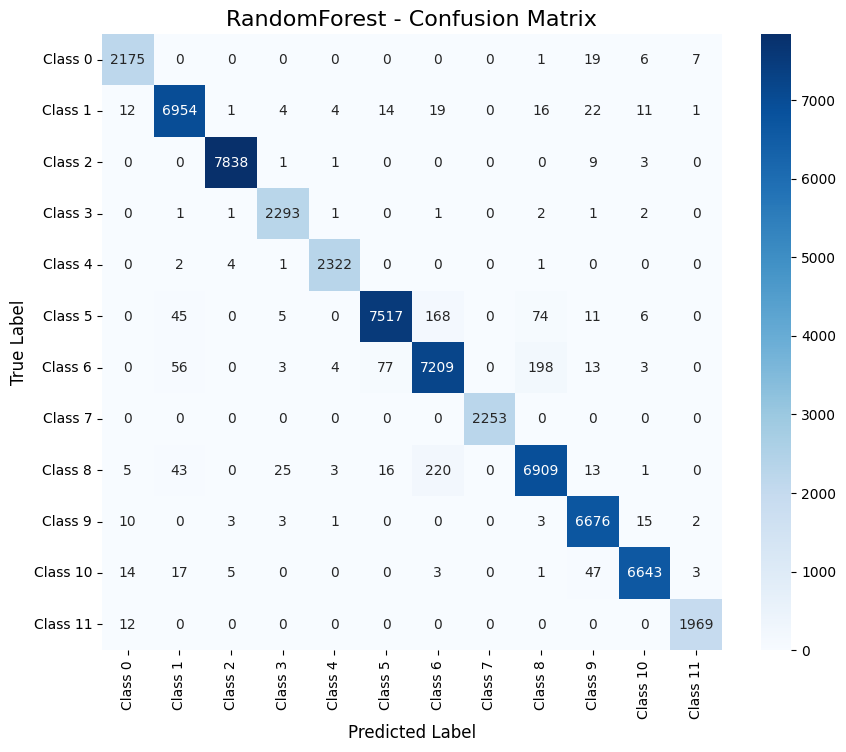


DEEP ANALYSIS FOR: XGBOOST
INFO: XGBoost will attempt to use GPU acceleration.

Training XGBoost...
Training complete in 4.34 seconds.

Evaluating on the test set...

Overall Test Set Accuracy: 0.9420

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Class 0     0.9502    0.9678    0.9589      2208
     Class 1     0.9342    0.9530    0.9435      7058
     Class 2     0.9940    0.9918    0.9929      7852
     Class 3     0.9773    0.9913    0.9843      2302
     Class 4     0.9867    0.9906    0.9886      2330
     Class 5     0.9435    0.8991    0.9208      7826
     Class 6     0.8583    0.8750    0.8666      7563
     Class 7     1.0000    0.9996    0.9998      2253
     Class 8     0.8861    0.8744    0.8802      7235
     Class 9     0.9524    0.9796    0.9658      6713
    Class 10     0.9708    0.9575    0.9641      6733
    Class 11     0.9824    0.9874    0.9849      1981

    accuracy                         0.9420     62054


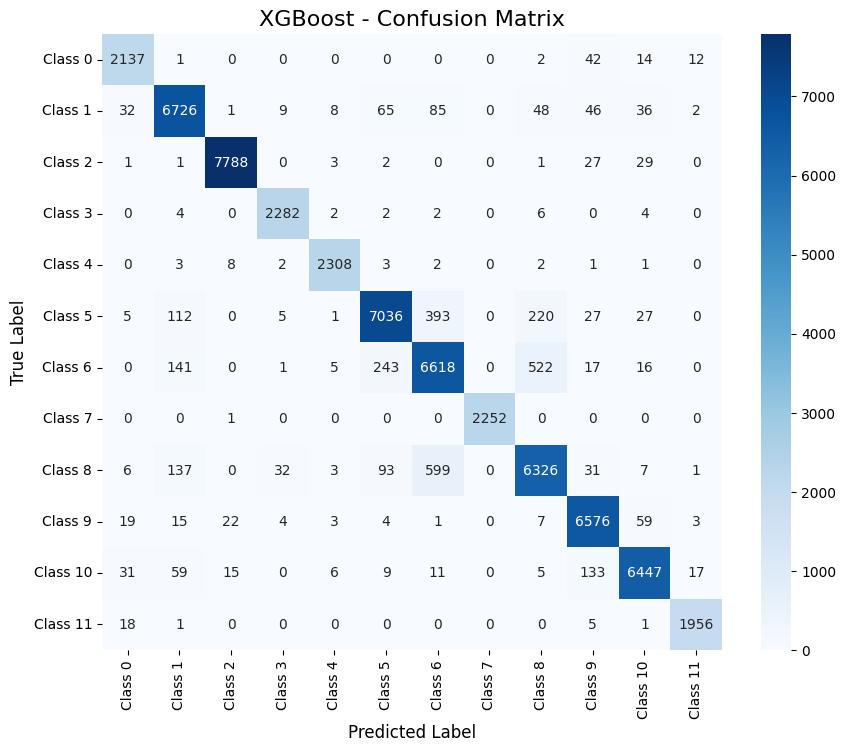

In [2]:
# --- Step 1: Install XGBoost ---
# This cell should be run first.
!pip install -q xgboost

import numpy as np
import pandas as pd
import os
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn and XGBoost components
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

def load_and_prep_data(file_path: str, test_size: float = 0.2, multiclass: bool = True):
    """
    Loads data, performs balancing (for binary) or uses original distribution (for multi-class),
    and splits the data for training and testing.
    """
    print("\n" + "="*50)
    print("LOADING AND PREPARING DATA FOR CLASSICAL BENCHMARKING")
    print("="*50)

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    data = np.load(file_path)
    print(f"Loaded data from '{os.path.basename(file_path)}' with shape: {data.shape}")

    X = data[:, :-1]
    y = data[:, -1].astype(int)
    n_features = X.shape[1]
    
    unique_labels = np.unique(y)
    n_classes = len(unique_labels)
    print(f"Found {n_classes} unique classes: {unique_labels}")

    y_final = y
    X_final = X
    
    # If the problem is binary, balance the dataset for a fair comparison
    if not multiclass:
        print("Task is binary. Balancing the dataset...")
        y_binary = np.where(y == 0, 0, 1)
        
        ransomware_indices = np.where(y_binary == 1)[0]
        benign_indices = np.where(y_binary == 0)[0]
        min_samples = min(len(ransomware_indices), len(benign_indices))
        print(f"Balancing to {min_samples} samples per class.")
        
        balanced_ransomware_indices = np.random.choice(ransomware_indices, min_samples, replace=False)
        balanced_benign_indices = np.random.choice(benign_indices, min_samples, replace=False)
        balanced_indices = np.concatenate([balanced_ransomware_indices, balanced_benign_indices])
        np.random.shuffle(balanced_indices)
        
        X_final = X[balanced_indices]
        y_final = y_binary[balanced_indices]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_final, y_final, test_size=test_size, random_state=42, stratify=y_final
    )

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("\nDATASET SUMMARY")
    print(f"Number of features: {n_features}")
    print(f"Training samples: {len(X_train)}")
    print(f"Testing samples: {len(X_test)}")

    return X_train_scaled, X_test_scaled, y_train, y_test

def train_and_evaluate_model(model_name: str, X_train, X_test, y_train, y_test):
    """
    Initializes, trains, and provides in-depth evaluation for a specified classical model.
    """
    print("\n" + "="*50)
    print(f"DEEP ANALYSIS FOR: {model_name.upper()}")
    print("="*50)

    # Initialize the chosen model
    if model_name.lower() == 'randomforest':
        # n_jobs=-1 uses all available CPU cores
        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
    elif model_name.lower() == 'xgboost':
        # Automatically attempt to use GPU for faster training
        try:
            model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, 
                                  eval_metric='mlogloss', tree_method='gpu_hist')
            print("INFO: XGBoost will attempt to use GPU acceleration.")
        except Exception as e:
            print("WARNING: GPU not available for XGBoost, falling back to CPU. Reason:", e)
            model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, 
                                  eval_metric='mlogloss', n_jobs=-1)
    else:
        raise ValueError("Model not supported. Choose 'RandomForest' or 'XGBoost'.")

    # Train the model and time the process
    print(f"\nTraining {model_name}...")
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training complete in {training_time:.2f} seconds.")

    # Make predictions
    print("\nEvaluating on the test set...")
    y_pred = model.predict(X_test)

    # --- In-Depth Analysis ---
    n_classes = len(np.unique(np.concatenate([y_train, y_test])))
    target_names = [f"Class {i}" for i in range(n_classes)]
    if n_classes == 2:
        target_names = ["Benign", "Ransomware"]
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nOverall Test Set Accuracy: {accuracy:.4f}\n")
    
    print("--- Detailed Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=target_names, digits=4, zero_division=0))

    # Plot confusion matrix
    print("\n--- Confusion Matrix ---")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10 if n_classes > 2 else 7, 8 if n_classes > 2 else 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{model_name} - Confusion Matrix', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()

# --- Main Execution: Your Control Panel ---
if __name__ == "__main__":
    # --- CHOOSE YOUR EXPERIMENT ---
    # 1. Select the dataset file to test by uncommenting one line:
    # --- Binary Classification ---
    # npy_file = "RANSAP_win7-120gb-hdd_2CLASS.npy"
    # npy_file = "RANSAP_win7-120gb-ssd_2CLASS.npy"
    
    # --- Multi-Class Classification ---
    npy_file = "/kaggle/input/ransap-feature-extracted2/RANSAP_win7-120gb-hdd_12CLASS.npy"
    # npy_file = "RANSAP_win7-120gb-ssd_12CLASS.npy"
    # npy_file = "RANSAP_win7-120gb-hdd_26CLASS.npy"
    
    # 2. Set 'is_multiclass' based on your choice above
    #    True for 12/26-class files, False for 2-class files.
    is_multiclass = True
    
    # 3. Choose which classical models to run
    models_to_run = ['RandomForest', 'XGBoost']
    # ------------------------------------

    if not os.path.exists(npy_file):
        print(f"FATAL: The file was not found -> '{npy_file}'")
    else:
        # Load data based on the experiment settings
        X_train, X_test, y_train, y_test = load_and_prep_data(
            file_path=npy_file,
            multiclass=is_multiclass
        )
        
        # Run the chosen models sequentially
        for model_name in models_to_run:
            train_and_evaluate_model(
                model_name=model_name,
                X_train=X_train,
                X_test=X_test,
                y_train=y_train,
                y_test=y_test
            )
